# Experiment 4b: LSTM-GATv2 Previous Window Attention (No Residual)

Uses **raw features from the previous non-overlapping window** to compute
GATv2 attention, then applies that graph for message passing on the current
window's LSTM hidden states. **No residual connection.**

**Toggle:** `ATTN_FEATURE_SOURCE` = `"straddle"` (200-dim) or `"equity_returns"` (20-dim)
- `equity_returns`: Fair comparison with rolling GCN (same input data)
- `straddle`: Richer features (vol, MACD, moneyness) that Pearson never sees

**Key question:** Does learned attention from past data outperform Pearson correlation?

## 1. Setup

In [61]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [62]:
import os
import sys

if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/repo/4YP-main


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio, sortino_ratio, max_drawdown,
    annual_return, annual_volatility, calmar_ratio,
)

import random
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Configuration

In [ ]:
# Attention feature source
# "straddle"       : all 10 straddle features from prev window (200-dim)
# "equity_returns" : equity log returns from prev window (20-dim, fair comparison with GCN)
ATTN_FEATURE_SOURCE = "equity_returns"

# Experiment identification
EXPERIMENT_NAME = f"4b_GATv2_prev_window_nores_{ATTN_FEATURE_SOURCE}"
SEED = 41

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
VOL_TARGET = 0.15
TRAIN_STRIDE = 20

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# GATv2 Hyperparameters
HIDDEN_LAYER_SIZE = 32
GAT_UNITS = 16
ATTN_HEADS = 4
LSTM_DROPOUT = 0.4
ATTN_DROPOUT = 0.2
LEARNING_RATE = 0.0003
MAX_GRADIENT_NORM = 1.0
BATCH_SIZE = 57

# Results
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_BASE = "/content/drive/MyDrive/FINAL_RESULTS"
else:
    RESULTS_BASE = "FINAL_RESULTS"

print(f"Experiment: {EXPERIMENT_NAME} (seed={SEED})")
print(f"Attention features: {ATTN_FEATURE_SOURCE}")
print(f"Residual: REMOVED")
print(f"Train: {TRAIN_START}-{TEST_START}, Test: {TEST_START}-{TEST_END}")
print(f"LSTM hidden: {HIDDEN_LAYER_SIZE}, GAT: {GAT_UNITS}x{ATTN_HEADS}")
print(f"Dropout: LSTM={LSTM_DROPOUT}, Attn={ATTN_DROPOUT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Experiment: 4b_GATv2_prev_window_nores_equity_returns (seed=41)
Attention features: equity_returns
Residual: REMOVED
Train: 2011-2017, Test: 2017-2023
LSTM hidden: 32, GAT: 16x4
Dropout: LSTM=0.4, Attn=0.2


## 3. Helper Functions

In [65]:
def calc_daily_returns(df, returns_col="captured_returns"):
    num_tickers = df["identifier"].nunique()
    daily_ret = df.groupby("time")[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()

def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        return daily_returns * (target_vol / current_vol)
    return daily_returns

def calc_metrics(daily_returns, name="Strategy"):
    return {
        "Strategy": name, "E[Ret.]": annual_return(daily_returns),
        "Vol.": annual_volatility(daily_returns), "Sharpe": sharpe_ratio(daily_returns),
        "Sortino": sortino_ratio(daily_returns), "Max DD": -max_drawdown(daily_returns),
        "Calmar": calmar_ratio(daily_returns), "Hit Rate": (daily_returns > 0).mean(),
        "Avg P/L": daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }

def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    scaled = calc_vol_scaled_returns(daily_returns, target_vol)
    return calc_metrics(scaled, name + " (Vol-Norm)"), scaled

def display_metrics(metrics_dict):
    df = pd.DataFrame([metrics_dict]).set_index("Strategy")
    for col in ["E[Ret.]", "Vol.", "Max DD", "Hit Rate"]:
        if col in df.columns: df[col] = df[col].apply(lambda x: f"{x:.2%}")
    for col in ["Sharpe", "Sortino", "Calmar", "Avg P/L"]:
        if col in df.columns: df[col] = df[col].apply(lambda x: f"{x:.3f}")
    display(df)

def calc_yearly_sharpes(daily_returns):
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly

def plot_results(daily_returns_dict, title="Strategy Comparison"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title("Cumulative Returns"); ax1.legend(loc="upper left", fontsize=8); ax1.grid(True, alpha=0.3)
    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod(); dd = (cum - cum.cummax()) / cum.cummax()
        ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title("Drawdown"); ax2.legend(loc="lower left", fontsize=8); ax2.grid(True, alpha=0.3)
    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rs = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rs.index, rs.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
    ax3.set_title("Rolling 252-Day Sharpe"); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
    ax4 = axes[1, 1]
    yearly_df = pd.DataFrame({n: calc_yearly_sharpes(r) for n, r in daily_returns_dict.items()})
    yearly_df.plot(kind="bar", ax=ax4, width=0.8)
    ax4.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
    ax4.set_title("Yearly Sharpe"); ax4.tick_params(axis="x", rotation=45); ax4.grid(True, alpha=0.3, axis="y")
    plt.suptitle(title, fontsize=14, fontweight="bold"); plt.tight_layout(); plt.show()

## 4. Data Loading

In [66]:
features_path = "data/straddle_features/features.csv"
if 'google.colab' in str(get_ipython()):
    features_path = "/content/drive/MyDrive/features.csv"

df = pd.read_csv(features_path)
df["date"] = pd.to_datetime(df["date"])
print(f"Loaded {len(df)} rows, {df['ticker'].nunique()} tickers")

Loaded 274384 rows, 88 tickers


In [67]:
from gml.graph_model_inputs import GraphModelFeatures

features = GraphModelFeatures(
    df=df, total_time_steps=TOTAL_TIME_STEPS, start_boundary=TRAIN_START,
    test_boundary=TEST_START, test_end=TEST_END, train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True, time_features=False, train_valid_sliding=True,
)

train_all = {k: v[::TRAIN_STRIDE] for k, v in features.train.items()}
valid_all = {k: v[::TRAIN_STRIDE] for k, v in features.valid.items()}
test_all = features.test_sliding

print(f"Train: {train_all['inputs'].shape[0]}, Valid: {valid_all['inputs'].shape[0]}, Test: {test_all['inputs'].shape[0]}")

no lags


train _batch
After final stacking and culling:
inputs.shape: (1131, 88, 20, 10)
outputs.shape: (1131, 88, 20, 1)
active_entries.shape: (1131, 88, 20, 1)
identifier.shape: (1131, 88, 20, 1)
date.shape: (1131, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (269, 88, 20, 10)
outputs.shape: (269, 88, 20, 1)
active_entries.shape: (269, 88, 20, 1)
identifier.shape: (269, 88, 20, 1)
date.shape: (269, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
Train: 57, Valid: 14, Test: 1400


## 5. Pair Consecutive Windows

In [68]:
def pair_consecutive_windows(data, input_size, attn_feature_source="straddle",
                             equity_returns_pivot=None, date_key="date"):
    inputs = data["inputs"]
    outputs = data["outputs"]
    active = data["active_entries"]
    N = inputs.shape[0]
    num_tickers = inputs.shape[1]
    time_steps = inputs.shape[2]

    if attn_feature_source == "straddle":
        prev_flat = inputs[:-1].reshape(N - 1, num_tickers, -1)
        prev_feature_dim = time_steps * input_size
    elif attn_feature_source == "equity_returns":
        if equity_returns_pivot is None:
            raise ValueError("equity_returns_pivot required for equity_returns mode")
        dates = data[date_key]
        tickers = sorted(equity_returns_pivot.columns.tolist())
        prev_features_list = []
        for w in range(N - 1):
            window_dates = pd.to_datetime(dates[w, 0, :, 0])
            equity_window = equity_returns_pivot.reindex(window_dates).fillna(0.0)
            equity_arr = equity_window[tickers[:num_tickers]].values.T
            prev_features_list.append(equity_arr)
        prev_flat = np.array(prev_features_list)
        prev_feature_dim = time_steps
    else:
        raise ValueError(f"Unknown attn_feature_source: {attn_feature_source}")

    curr_features = inputs[1:]
    curr_outputs = outputs[1:]
    curr_weights = active[1:]

    print(f"Paired {N} windows -> {N-1} pairs")
    print(f"  prev_features: {prev_flat.shape} (dim={prev_feature_dim})")
    print(f"  curr_features: {curr_features.shape}")
    return prev_flat, curr_features, curr_outputs, curr_weights, prev_feature_dim

In [69]:
equity_returns_pivot = None
if ATTN_FEATURE_SOURCE == "equity_returns":
    cache_path = os.path.join("data", "graph_structure", "equity_returns", "log_returns.csv")
    if os.path.exists(cache_path):
        equity_returns_pivot = pd.read_csv(cache_path, index_col=0, parse_dates=True).sort_index()
        print(f"Loaded equity returns: {equity_returns_pivot.shape}")
    else:
        raise FileNotFoundError(f"Equity returns cache not found at {cache_path}")

input_size = train_all["inputs"].shape[3]

print("Training:")
prev_train, curr_train, y_train, w_train, prev_feature_dim = pair_consecutive_windows(
    train_all, input_size, ATTN_FEATURE_SOURCE, equity_returns_pivot)
print("Validation:")
prev_valid, curr_valid, y_valid, w_valid, _ = pair_consecutive_windows(
    valid_all, input_size, ATTN_FEATURE_SOURCE, equity_returns_pivot)
print("Test:")
prev_test, curr_test, y_test, w_test, _ = pair_consecutive_windows(
    test_all, input_size, ATTN_FEATURE_SOURCE, equity_returns_pivot)

print(f"Attention feature source: {ATTN_FEATURE_SOURCE} (dim={prev_feature_dim})")

Loaded equity returns: (3773, 88)
Training:
Paired 57 windows -> 56 pairs
  prev_features: (56, 88, 20) (dim=20)
  curr_features: (56, 88, 20, 10)
Validation:
Paired 14 windows -> 13 pairs
  prev_features: (13, 88, 20) (dim=20)
  curr_features: (13, 88, 20, 10)
Test:
Paired 1400 windows -> 1399 pairs
  prev_features: (1399, 88, 20) (dim=20)
  curr_features: (1399, 88, 20, 10)
Attention feature source: equity_returns (dim=20)


## 6. Model Definition

In [70]:
from gml.graph_attention_v2 import build_lstm_gat_e2e_v3_prev_window

num_tickers = curr_train.shape[1]
time_steps = curr_train.shape[2]

print(f"Building LSTM-GATv2 Prev Window v3 (NO RESIDUAL):")
print(f"  num_tickers: {num_tickers}, time_steps: {time_steps}, input_size: {input_size}")
print(f"  prev_feature_dim: {prev_feature_dim}")

model = build_lstm_gat_e2e_v3_prev_window(
    num_tickers=num_tickers, time_steps=time_steps, input_size=input_size,
    hidden_layer_size=HIDDEN_LAYER_SIZE, gat_units=GAT_UNITS, attn_heads=ATTN_HEADS,
    lstm_dropout=LSTM_DROPOUT, attn_dropout=ATTN_DROPOUT,
    learning_rate=LEARNING_RATE, max_gradient_norm=MAX_GRADIENT_NORM,
    prev_feature_dim=prev_feature_dim,
)

print(f"Total parameters: {model.count_params():,}")

Building LSTM-GATv2 Prev Window v3 (NO RESIDUAL):
  num_tickers: 88, time_steps: 20, input_size: 10
  prev_feature_dim: 20
Total parameters: 10,193


## 7. Training

In [71]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1)

print("=" * 60)
print(f"Training {EXPERIMENT_NAME} (seed={SEED})")
print(f"  NO RESIDUAL | Attn source: {ATTN_FEATURE_SOURCE} (dim={prev_feature_dim})")
print("=" * 60)

history = model.fit(
    [prev_train, curr_train], y_train, sample_weight=w_train,
    validation_data=([prev_valid, curr_valid], y_valid, w_valid),
    epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stopping], verbose=1,
)

Training 4b_GATv2_prev_window_nores_equity_returns (seed=41)
  NO RESIDUAL | Attn source: equity_returns (dim=20)
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 72s 72s/step - loss: -0.4705 - val_loss: -0.9392
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step - loss: -0.5637 - val_loss: -0.9491
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: -0.6117 - val_loss: -0.9654
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: -0.6602 - val_loss: -0.9779
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step - loss: -0.6521 - val_loss: -0.9853
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step - loss: -0.7090 - val_loss: -0.9896
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step - loss: -0.7038 - val_loss: -0.9938
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step - loss: -0.7282 - val_loss: -0.9988
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: -0.7333 - val_loss: -1.0035
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step - loss: -0.7516 - val_loss: -1.0109
Epoch 11/300
1/1 ━━━━━━━━

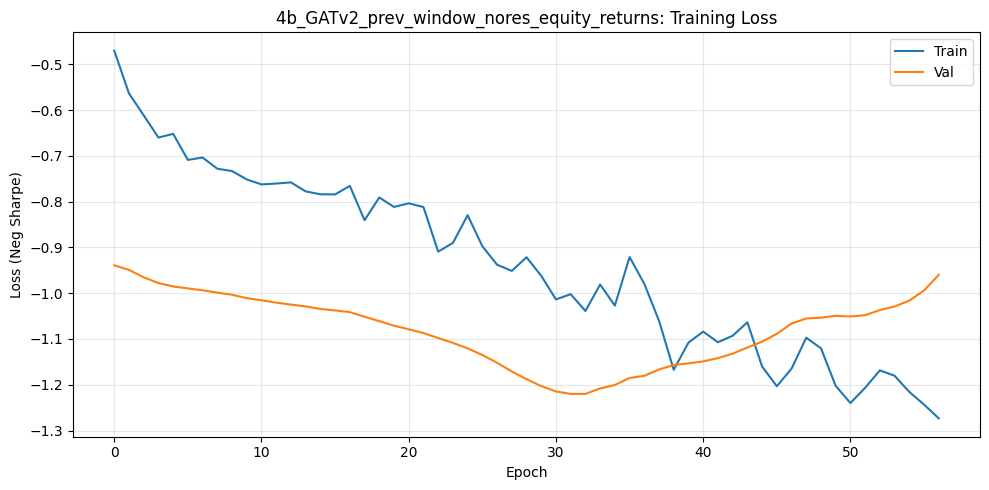

Epochs: 57, Best val: -1.2199


In [72]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.xlabel("Epoch"); plt.ylabel("Loss (Neg Sharpe)")
plt.title(f"{EXPERIMENT_NAME}: Training Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Epochs: {len(history.history['loss'])}, Best val: {min(history.history['val_loss']):.4f}")

## 8. Evaluation

In [73]:
predictions = model.predict([prev_test, curr_test])
print(f"Predictions shape: {predictions.shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 480ms/step
Predictions shape: (1399, 88, 20, 1)


In [74]:
positions = predictions[:, :, -1, 0].reshape(-1)
returns = y_test[:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

test_dates_full = test_all["date"][1:]
test_ids = test_all["identifier"][1:]
dates = test_dates_full[:, :, -1, 0].reshape(-1)
identifiers = test_ids[:, :, -1, 0].reshape(-1)

results_df = pd.DataFrame({
    "time": dates, "identifier": identifiers,
    "position": positions, "returns": returns, "captured_returns": captured_returns,
})
results_df["time"] = pd.to_datetime(results_df["time"])
results_df = results_df[results_df["identifier"] != "0"]
print(f"Results: {len(results_df)} rows")

Results: 123112 rows


In [75]:
daily_returns = calc_daily_returns(results_df)

print("" + "=" * 60)
print(f"{EXPERIMENT_NAME} Results (Raw)")
print("=" * 60)
metrics_raw = calc_metrics(daily_returns, EXPERIMENT_NAME)
display_metrics(metrics_raw)

print(f"Vol-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, EXPERIMENT_NAME, VOL_TARGET)
display_metrics(metrics_norm)

print("Yearly Sharpes:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, s in yearly_sharpes.items():
    print(f"  {year}: {s:.4f}")

4b_GATv2_prev_window_nores_equity_returns Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
4b_GATv2_prev_window_nores_equity_returns,0.31%,0.37%,0.829,1.108,0.67%,0.460,56.47%,0.942


Vol-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
4b_GATv2_prev_window_nores_equity_returns (Vol-Norm),11.95%,15.00%,0.829,1.108,25.29%,0.473,56.47%,0.942


Yearly Sharpes:
  2017: 3.2862
  2018: -0.3058
  2019: 1.9937
  2020: -0.0587
  2021: 1.2158
  2022: 1.3224


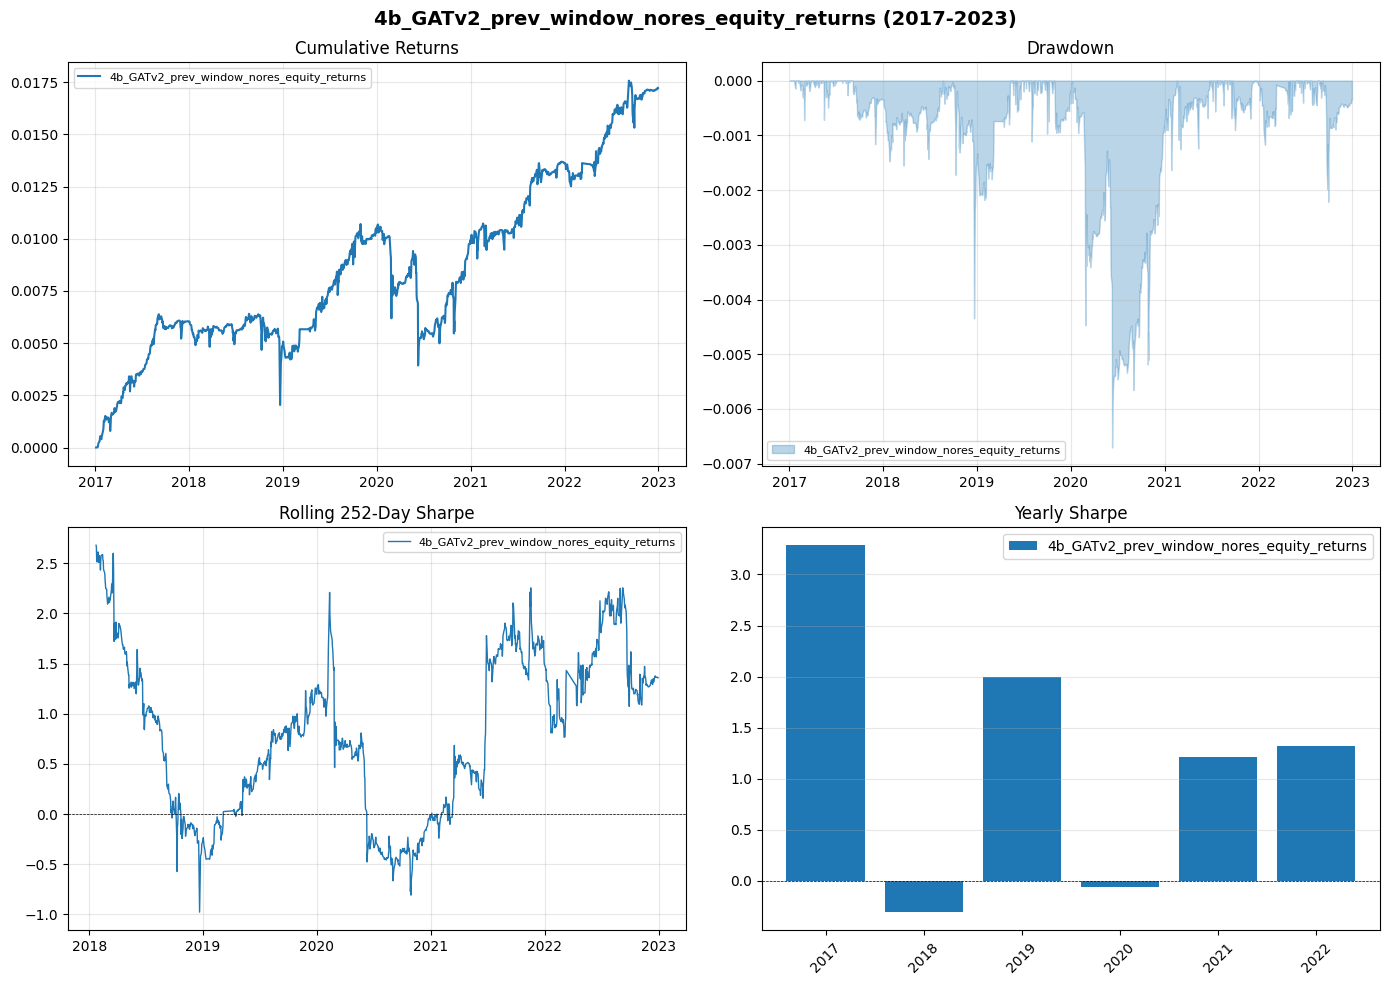

In [76]:
plot_results({EXPERIMENT_NAME: daily_returns}, f"{EXPERIMENT_NAME} ({TEST_START}-{TEST_END})")

## 9. Attention Analysis

In [77]:
from gml.experiment_utils import compute_graph_stats

# Extract attention weights
gat_layer = model.get_layer("prev_window_gat")
W_src = gat_layer.W_src.numpy()
W_dst = gat_layer.W_dst.numpy()
a = gat_layer.a.numpy()
num_heads = W_src.shape[0]

def compute_attention_from_prev(prev_features, W_src, W_dst, a):
    num_heads = W_src.shape[0]
    N = prev_features.shape[0]
    all_attn = []
    for idx in range(N):
        sample = prev_features[idx]
        head_attns = []
        for h in range(num_heads):
            h_src = sample @ W_src[h]
            h_dst = sample @ W_dst[h]
            pairwise = h_src[:, np.newaxis, :] + h_dst[np.newaxis, :, :]
            pairwise = np.where(pairwise > 0, pairwise, 0.2 * pairwise)
            scores = (pairwise @ a[h]).squeeze(-1)
            exp_s = np.exp(scores - scores.max(axis=-1, keepdims=True))
            attn = exp_s / (exp_s.sum(axis=-1, keepdims=True) + 1e-9)
            head_attns.append(attn)
        all_attn.append(np.stack(head_attns, axis=0))
    return np.array(all_attn)

print(f"Extracting attention for {prev_test.shape[0]} test windows...")
all_attn = compute_attention_from_prev(prev_test, W_src, W_dst, a)
all_graphs_avg = all_attn.mean(axis=1)
print(f"Done: {all_graphs_avg.shape}")

test_dates_arr = pd.to_datetime(test_all["date"][1:, 0, -1, 0])

entropy = -np.sum(all_graphs_avg * np.log(all_graphs_avg + 1e-9), axis=-1)
mean_entropy = entropy.mean()
max_entropy = np.log(all_graphs_avg.shape[-1])
print(f"Attention entropy: {mean_entropy:.3f} (uniform = {max_entropy:.3f})")
print(f"Entropy ratio: {mean_entropy / max_entropy:.3f}")

EDGE_THRESHOLD = 0.02
graph_stats = compute_graph_stats(all_graphs_avg, threshold=EDGE_THRESHOLD)
print(f"Mean edges: {graph_stats['num_edges'].mean():.1f}, Max attn: {graph_stats['max_attn'].mean():.4f}")

Extracting attention for 1399 test windows...
Done: (1399, 88, 88)
Attention entropy: 4.477 (uniform = 4.477)
Entropy ratio: 1.000
Mean edges: 0.0, Max attn: 0.0114


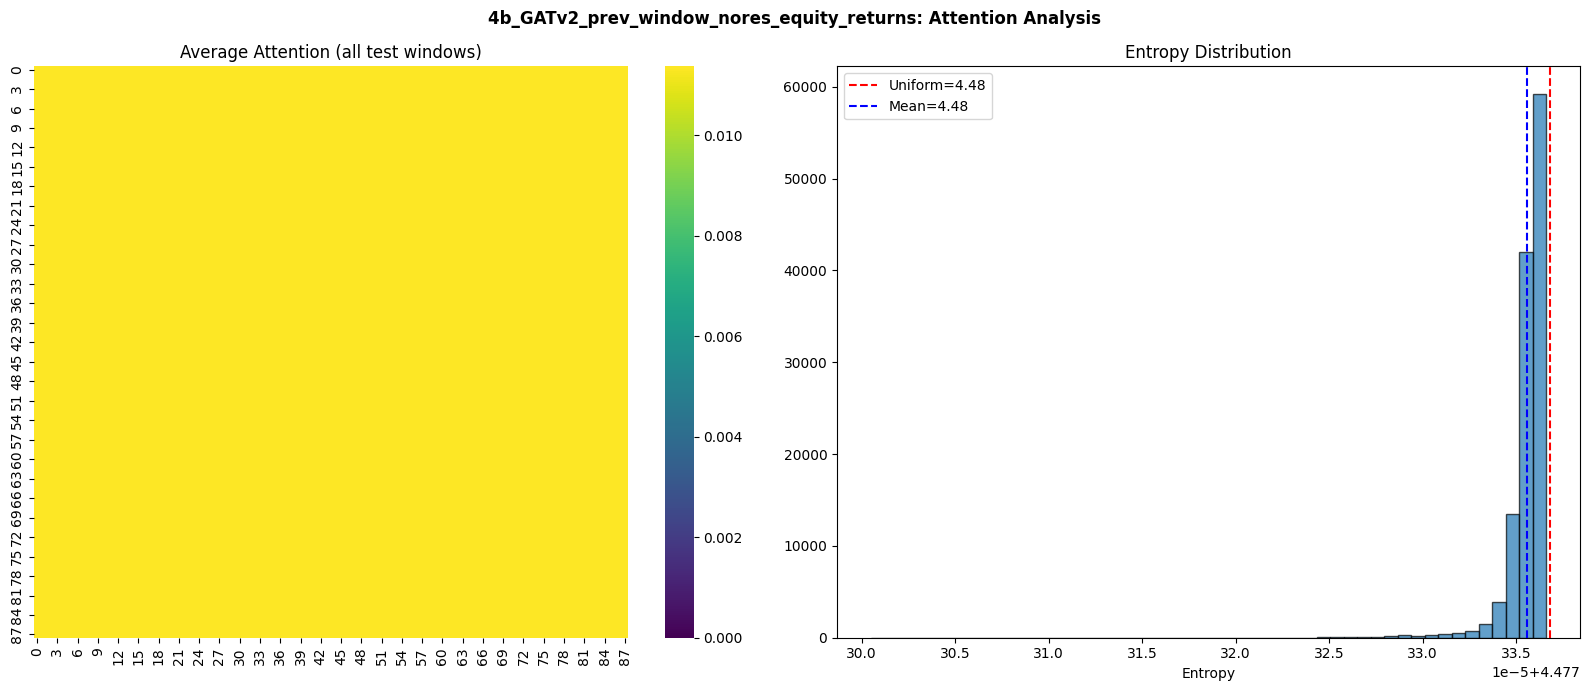

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
avg_attn = all_graphs_avg.mean(axis=0)
sns.heatmap(avg_attn, ax=axes[0], cmap="viridis", vmin=0)
axes[0].set_title("Average Attention (all test windows)")
axes[1].hist(entropy.flatten(), bins=50, edgecolor="black", alpha=0.7)
axes[1].axvline(x=max_entropy, color="red", linestyle="--", label=f"Uniform={max_entropy:.2f}")
axes[1].axvline(x=mean_entropy, color="blue", linestyle="--", label=f"Mean={mean_entropy:.2f}")
axes[1].set_xlabel("Entropy"); axes[1].set_title("Entropy Distribution"); axes[1].legend()
plt.suptitle(f"{EXPERIMENT_NAME}: Attention Analysis", fontweight="bold"); plt.tight_layout(); plt.show()

## 10. Graph Statistics Over Time

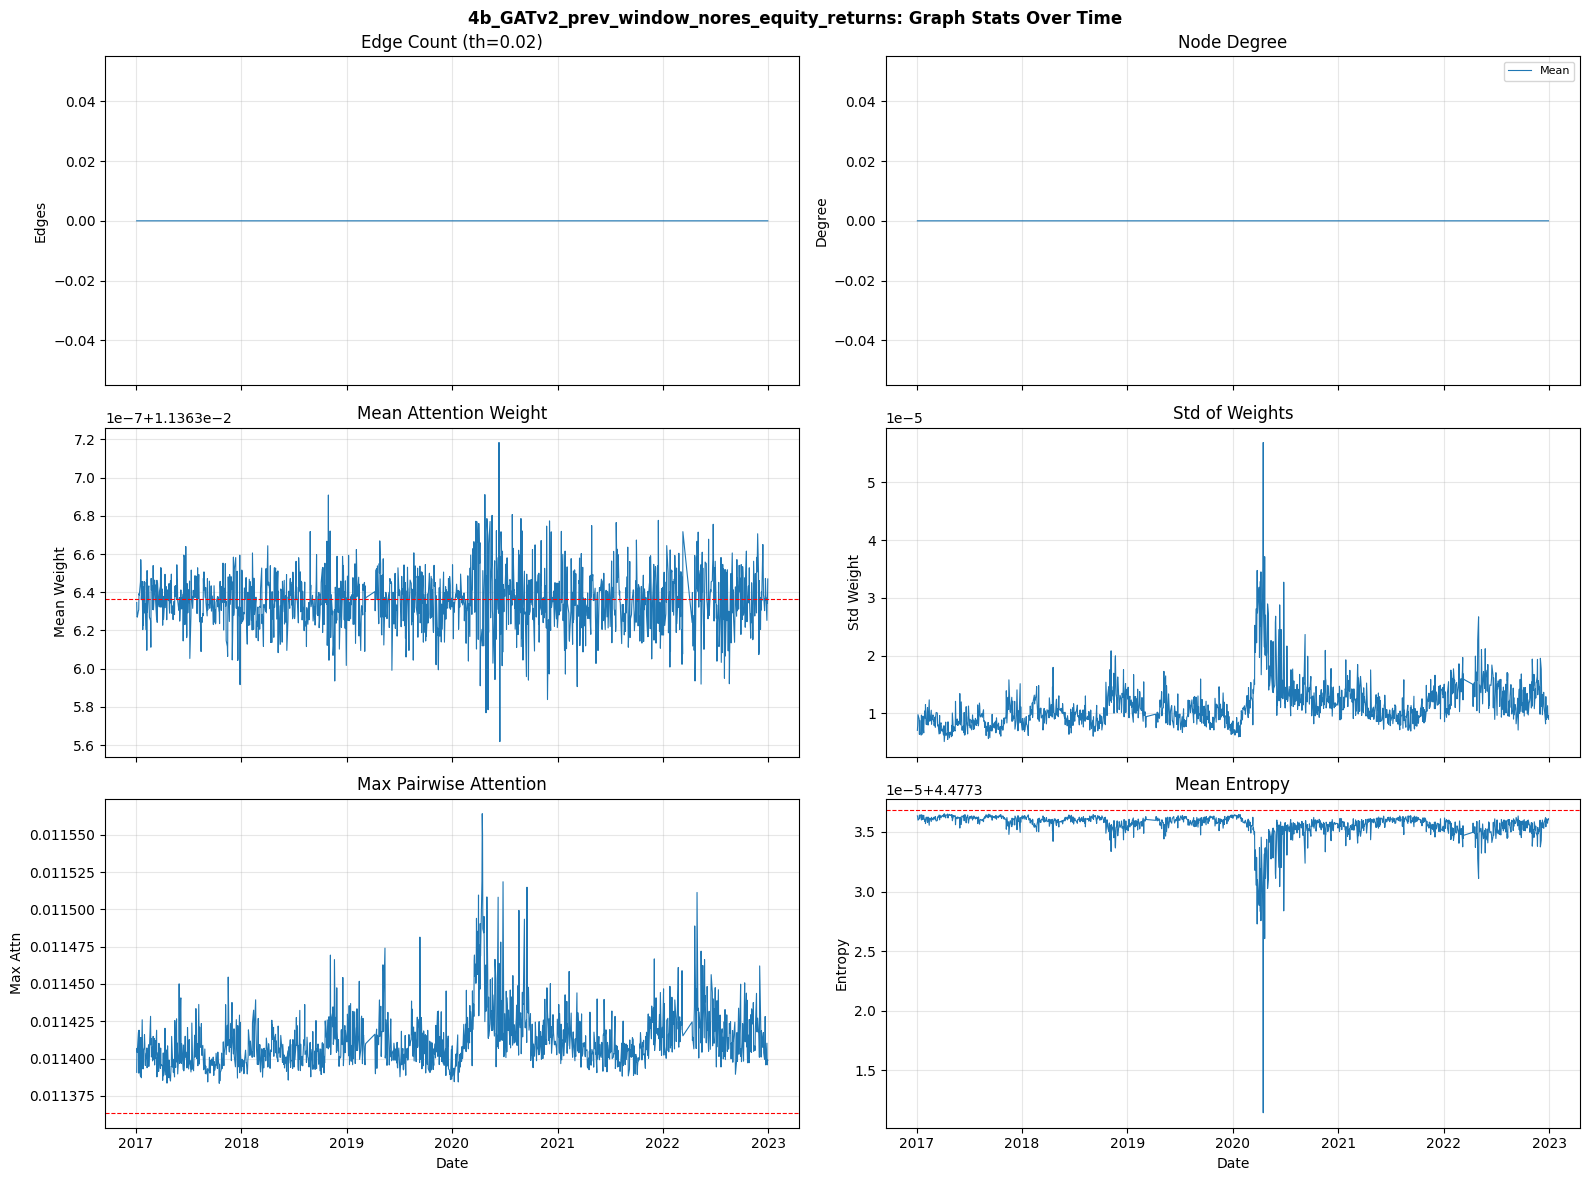

In [79]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
uniform_val = 1 / all_graphs_avg.shape[-1]
uniform_ent = np.log(all_graphs_avg.shape[-1])

axes[0,0].plot(test_dates_arr, graph_stats["num_edges"], lw=0.8); axes[0,0].set_ylabel("Edges"); axes[0,0].set_title(f"Edge Count (th={EDGE_THRESHOLD})"); axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(test_dates_arr, graph_stats["mean_degree"], lw=0.8, label="Mean"); axes[0,1].fill_between(test_dates_arr, graph_stats["min_degree"], graph_stats["max_degree"], alpha=0.2); axes[0,1].set_ylabel("Degree"); axes[0,1].set_title("Node Degree"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(test_dates_arr, graph_stats["mean_edge_weight"], lw=0.8); axes[1,0].axhline(y=uniform_val, color="red", ls="--", lw=0.8); axes[1,0].set_ylabel("Mean Weight"); axes[1,0].set_title("Mean Attention Weight"); axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(test_dates_arr, graph_stats["std_edge_weight"], lw=0.8); axes[1,1].set_ylabel("Std Weight"); axes[1,1].set_title("Std of Weights"); axes[1,1].grid(True, alpha=0.3)
axes[2,0].plot(test_dates_arr, graph_stats["max_attn"], lw=0.8); axes[2,0].axhline(y=uniform_val, color="red", ls="--", lw=0.8); axes[2,0].set_ylabel("Max Attn"); axes[2,0].set_xlabel("Date"); axes[2,0].set_title("Max Pairwise Attention"); axes[2,0].grid(True, alpha=0.3)
axes[2,1].plot(test_dates_arr, graph_stats["mean_entropy"], lw=0.8); axes[2,1].axhline(y=uniform_ent, color="red", ls="--", lw=0.8); axes[2,1].set_ylabel("Entropy"); axes[2,1].set_xlabel("Date"); axes[2,1].set_title("Mean Entropy"); axes[2,1].grid(True, alpha=0.3)
plt.suptitle(f"{EXPERIMENT_NAME}: Graph Stats Over Time", fontweight="bold"); plt.tight_layout(); plt.show()

## 11. Interactive Graph Visualization

In [80]:
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
from settings.default import ALL_TICKERS, BBG_SECTORS

SECTOR_COLORS = {
    "Information Technology": "#1f77b4", "Healthcare": "#2ca02c",
    "Financials": "#ff7f0e", "Consumer Discretionary": "#d62728",
    "Consumer Staples": "#9467bd", "Industrials": "#8c564b",
    "Communication Services": "#e377c2", "Energy": "#7f7f7f",
    "Utilities": "#bcbd22", "Real Estate": "#17becf",
}
tickers = sorted(ALL_TICKERS)
G_ref = nx.Graph()
for t in tickers: G_ref.add_node(t)
fixed_pos = nx.spring_layout(G_ref, k=2.5, iterations=100, seed=42)
node_colors = [SECTOR_COLORS.get(BBG_SECTORS.get(t, "Unknown"), "#cccccc") for t in tickers]
rolling_sharpe = daily_returns.rolling(252).mean() / daily_returns.rolling(252).std() * np.sqrt(252)

output_widget = widgets.Output()
def update_graph(window_idx):
    with output_widget:
        clear_output(wait=True)
        fig, (ax_g, ax_s) = plt.subplots(2, 1, figsize=(14, 16), gridspec_kw={"height_ratios": [3, 1]})
        adj = all_graphs_avg[window_idx]
        date_str = str(test_dates_arr[window_idx].date()) if window_idx < len(test_dates_arr) else "N/A"
        G = nx.Graph()
        for t in tickers: G.add_node(t)
        n = len(tickers)
        for i in range(n):
            for j in range(i+1, n):
                w = (adj[i,j] + adj[j,i]) / 2
                if w > EDGE_THRESHOLD: G.add_edge(tickers[i], tickers[j], weight=w)
        edges = G.edges(data=True)
        if len(edges) > 0:
            max_w = max(d["weight"] for _,_,d in edges)
            for (u,v,d) in edges:
                w = d["weight"]; ax_g.plot([fixed_pos[u][0], fixed_pos[v][0]], [fixed_pos[u][1], fixed_pos[v][1]], color="gray", lw=2*w/max_w, alpha=0.3+0.7*w/max_w, zorder=1)
        nx.draw_networkx_nodes(G, fixed_pos, node_color=node_colors, node_size=600, alpha=0.9, ax=ax_g)
        nx.draw_networkx_labels(G, fixed_pos, font_size=6, font_weight="bold", ax=ax_g)
        ax_g.set_title(f"Attention Graph at {date_str} | {G.number_of_edges()} edges (th={EDGE_THRESHOLD})", fontsize=14, fontweight="bold"); ax_g.axis("off")
        ax_s.plot(rolling_sharpe.index, rolling_sharpe.values, lw=1, color="blue")
        ax_s.axhline(y=0, color="black", ls="--", lw=0.5)
        if window_idx < len(test_dates_arr): ax_s.axvline(x=test_dates_arr[window_idx], color="red", lw=2, alpha=0.8)
        ax_s.set_title("Rolling 252-Day Sharpe"); ax_s.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

slider = widgets.IntSlider(min=0, max=len(all_graphs_avg)-1, step=1, value=0, description="Window:", continuous_update=False, layout=widgets.Layout(width="80%"))
widgets.interactive(update_graph, window_idx=slider)
display(slider, output_widget)
update_graph(0)

IntSlider(value=0, continuous_update=False, description='Window:', layout=Layout(width='80%'), max=1398)

Output()

## 12. Position Analysis

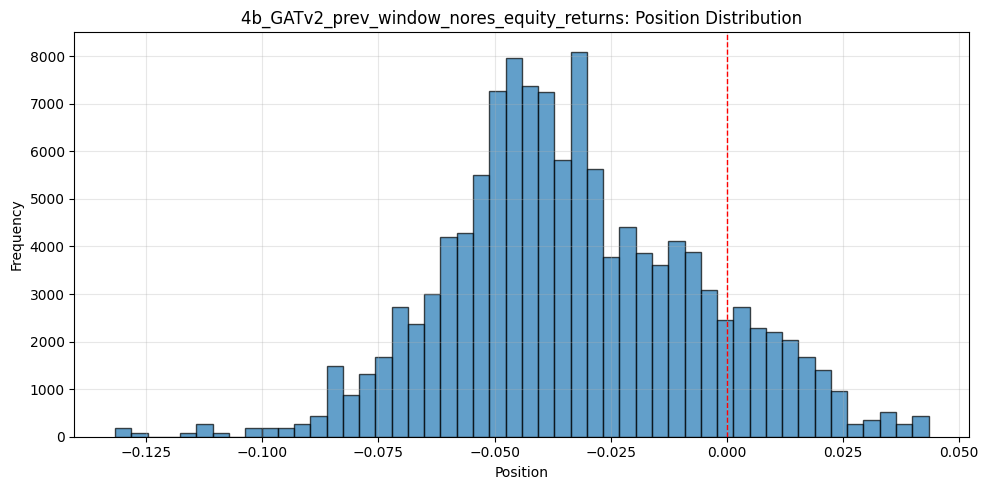

In [81]:
plt.figure(figsize=(10, 5))
plt.hist(results_df["position"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Position"); plt.ylabel("Frequency")
plt.title(f"{EXPERIMENT_NAME}: Position Distribution")
plt.axvline(x=0, color="red", ls="--", lw=1); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 13. Save Results

In [82]:
from gml.experiment_utils import save_experiment_results

hyperparams = {
    "hidden_layer_size": HIDDEN_LAYER_SIZE, "gat_units": GAT_UNITS,
    "attn_heads": ATTN_HEADS, "lstm_dropout": LSTM_DROPOUT,
    "attn_dropout": ATTN_DROPOUT, "learning_rate": LEARNING_RATE,
    "max_gradient_norm": MAX_GRADIENT_NORM, "batch_size": BATCH_SIZE,
    "train_stride": TRAIN_STRIDE, "residual": False,
    "model_type": "GATv2_prev_window_no_residual",
    "attn_feature_source": ATTN_FEATURE_SOURCE,
    "prev_feature_dim": prev_feature_dim,
    "total_time_steps": TOTAL_TIME_STEPS,
    "train_start": TRAIN_START, "test_start": TEST_START, "test_end": TEST_END,
}

save_experiment_results(
    experiment_name=EXPERIMENT_NAME, seed=SEED,
    predictions=predictions, results_df=results_df,
    daily_returns=daily_returns, metrics_raw=metrics_raw,
    metrics_norm=metrics_norm, yearly_sharpes=yearly_sharpes,
    training_history=history.history, hyperparams=hyperparams,
    test_dates=test_dates_arr.values, attention_weights=all_attn,
    graph_stats=graph_stats, model=model, base_dir=RESULTS_BASE,
)

Results saved to: /content/drive/MyDrive/FINAL_RESULTS/4b_GATv2_prev_window_nores_equity_returns/seed_41
Saved 12 files:
  captured_returns_sw.csv (8.2 MB)
  metrics_raw.csv (271 B)
  metrics_vol_normalized.csv (276 B)
  yearly_sharpes.csv (160 B)
  daily_returns.csv (46.2 KB)
  training_history.json (2.8 KB)
  hyperparams.json (440 B)
  predictions.npy (9.4 MB)
  test_dates.npy (11.1 KB)
  attention_weights.npy (330.6 MB)
  graph_stats.csv (128.5 KB)
  model_weights/weights.weights.h5 (327.0 KB)


## 14. Summary

In [83]:
print("=" * 60)
print(f"EXPERIMENT: {EXPERIMENT_NAME} (seed={SEED})")
print("=" * 60)
print(f"Model: LSTM-GATv2 Prev Window (NO RESIDUAL)")
print(f"Attn source: {ATTN_FEATURE_SOURCE} (dim={prev_feature_dim})")
print(f"Sharpe: {metrics_raw['Sharpe']:.3f}, Return: {metrics_raw['E[Ret.]']:.2%}, Vol: {metrics_raw['Vol.']:.2%}")
print(f"Entropy: {mean_entropy:.3f} / {max_entropy:.3f} (ratio: {mean_entropy/max_entropy:.3f})")
print(f"Saved to: {RESULTS_BASE}/{EXPERIMENT_NAME}/seed_{SEED}/")

EXPERIMENT: 4b_GATv2_prev_window_nores_equity_returns (seed=41)
Model: LSTM-GATv2 Prev Window (NO RESIDUAL)
Attn source: equity_returns (dim=20)
Sharpe: 0.829, Return: 0.31%, Vol: 0.37%
Entropy: 4.477 / 4.477 (ratio: 1.000)
Saved to: /content/drive/MyDrive/FINAL_RESULTS/4b_GATv2_prev_window_nores_equity_returns/seed_41/
